# Pytorch Custom Datasets

How do you get your own data into Pytorch?

# 0.0 Importing Pytorch and Setting up Device Agnostic Code

In [211]:
import pandas as pd
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device-agnostic code
device = torch.device("cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")

2.11.0


# 1.0 Get Data

Dataset is subset of Food 101 dataset which starts with 101 different classes of food

This dataset starts with 3 classes of food and only 10% of the images.

In [212]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

# If folder doesn't exist, download it and prepare it
if image_path.is_dir():
    print(f"{image_path} directory already exists...skipping download")
else:
    print(f"{image_path} directory does not exist, downloading...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
    print("downloading pizza_steak_sushi.zip...")
    f.write(request.content)

# Unzip
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza_steak_sushi.zip...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists...skipping download
downloading pizza_steak_sushi.zip...
Unzipping pizza_steak_sushi.zip...


# 2.0 Data Preparation and Data Exploration


In [213]:
import os
def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents
    :param dir_path:
    :type dir_path:
    :return:
    :rtype:
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [214]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza


In [215]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir


(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# 2.1 Visualize an Image

1. Get all the image paths
2. Pick a random image path using random.choice()
3. Get the image class name `pathlib.Path.parent.stem`
4. Open image with Python PIL
5. Show image and print metadata

Random image path: data/pizza_steak_sushi/test/pizza/2236338.jpg
Image class: pizza
Image height: 512
Image width: 512


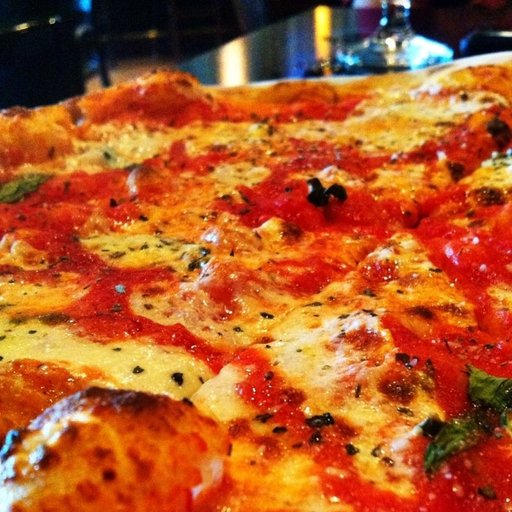

In [216]:
import random
from PIL import Image

# Set seed
random.seed(42)

# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Pick random image path
random_image_path = random.choice(image_path_list)

# Get image class
image_class = random_image_path.parent.stem

# Open image
img = Image.open(random_image_path)

# Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

Text(0.5, 1.0, 'Image class: pizza | Image shape: (512, 512, 3)')

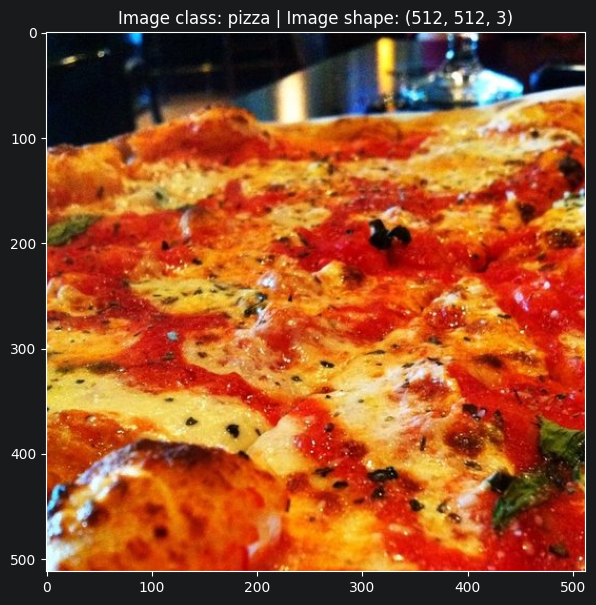

In [217]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)
# Plot image with matplot lib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}")


# 3.0 Transforming Data

Need to transform image data to tensors before manipulating with Pytorch

Create a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`

In [218]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

# 3.1 Transforming data with `torchvision.transforms`

In [219]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn image into torch tensor
    transforms.ToTensor(),
])

In [220]:
data_transform(img).shape

torch.Size([3, 64, 64])

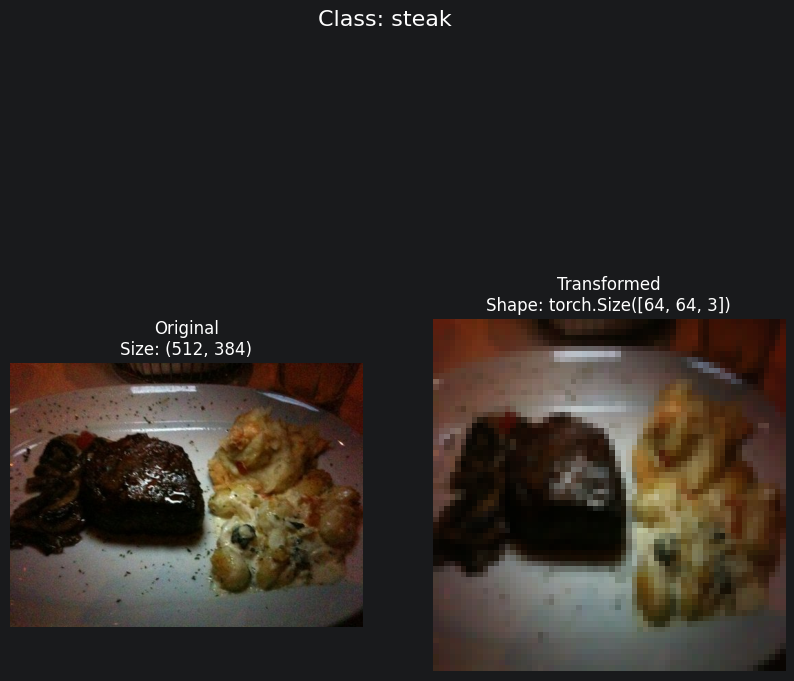

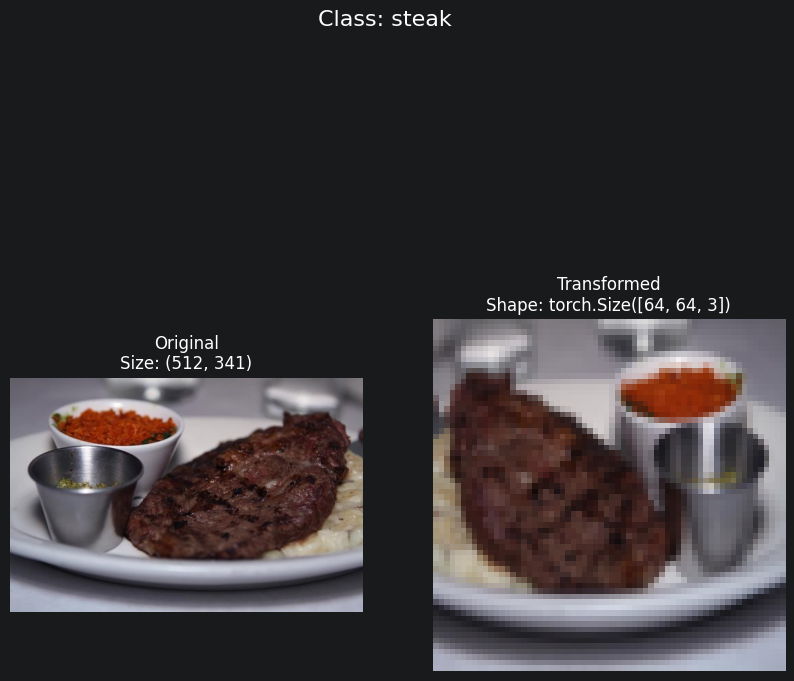

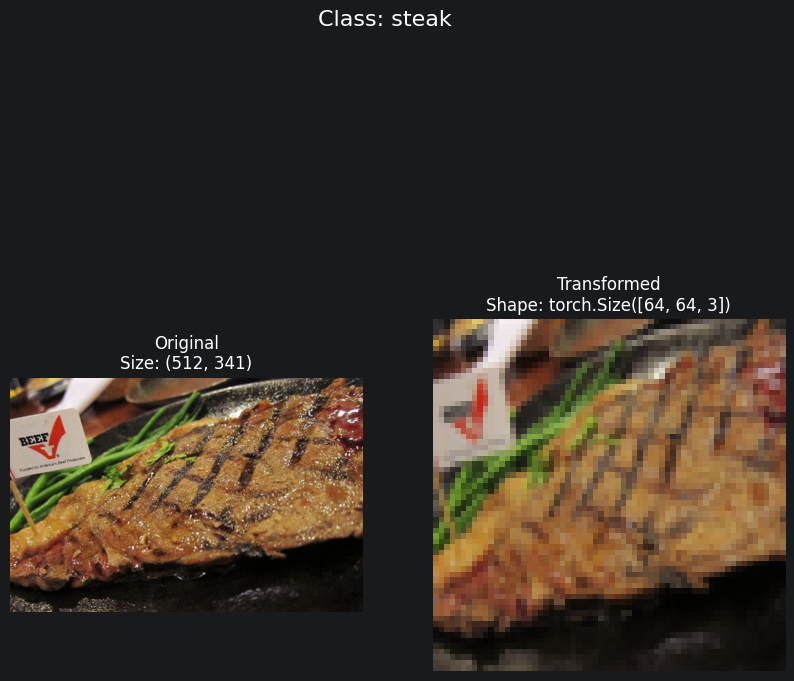

In [221]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None) -> None:
    """
    Selects random images from a path of images and loads/trasforms them then plots the original vs the transformed version
    :param image_paths:
    :type image_paths:
    :param transform:
    :type transform:
    :param n:
    :type n:
    :param seed:
    :type seed:
    :return:
    :rtype:
    """
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot the target image
            transformed_image = transform(f).permute(1, 2, 0) # (C, H, W) -> (H, W, C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, data_transform, n=3)


# 4.0 Option 1: Loading Image data using `ImageFolder`

Load image classification using `torchvision.datasets.ImageFolder`

In [222]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [223]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [224]:
# Get class names as dict

class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [225]:
# Check the lengths of the dataset
len(train_data), len(test_data)

(225, 75)

In [226]:
# Index on train_data Dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image Tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image Tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

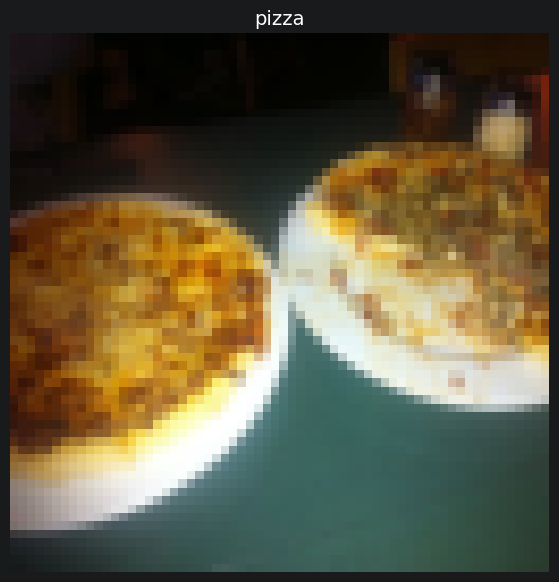

In [227]:
# Rearrange to order dimensions
img_permute = img.permute(1, 2, 0)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute: {img_permute.shape} -> [height, width, color_channels]")

# Plot image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14)

# 4.1 Turn loaded images into `DataLoader`s

A `DataLoader` is going to help us turn our Datasets into interables and we can customize batch_size so our model can see batch_size images at a time

In [228]:
# Turn train and test datasets into Dataloaders

from torch.utils.data import DataLoader
BATCH_SIZE = 1

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, num_workers=0, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers=0, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x12a568250>,
 <torch.utils.data.dataloader.DataLoader at 0x12a568350>)

In [229]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


# 5.0 Option 2: Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset



In [230]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset

# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx


(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# 5.1 Creating a helper function to get class names


In [231]:
# Setup path for target directory
target_directory = train_dir

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

['pizza', 'steak', 'sushi']

In [232]:
def find_classes(directory: str) -> tuple[list[str], dict[str, int]]:
    """
    Finds the class folder names in a target directory.
    :param directory:
    :type directory:
    :return:
    :rtype:
    """
    # Get class names by scanning target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"No classes found in {directory}")

    # Create dictionary of index labels
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# 5.2 Create a custom `Dataset` to replicate `ImageFolder`

* Subclass `torch.utils.data.Dataset`
* Init subclass with a target directory as well as a transform optionally
* Create several attributes:
*   paths - paths of images
*   transform - the transform we'd like to use
*   classes - a list of the target classes
*   class_to_idx - a dict of the target classes mapped to integer labels
* Create function to `load_images()`
* Override the `__len__()` method to return the length of our dataset
* Override the `__getitem__()` method to return a given sample when passed an index

In [233]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform

        self.paths = list(pathlib.Path(root).glob("*/*.jpg"))
        self.classes, self.class_to_idx = find_classes(root)

    def load_image(self, index: int) -> Image.Image:
        img_path = self.paths[index]
        return Image.open(img_path)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [234]:
# Create transform
train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
])

In [235]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(root=train_dir, transform=train_transforms)
test_data_custom = ImageFolderCustom(root=test_dir, transform=test_transforms)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x116b7a270>,
 <__main__.ImageFolderCustom at 0x12e8aa0d0>)

In [236]:
len(train_data), len(train_data_custom)

(225, 225)

In [237]:
len(test_data), len(test_data_custom)

(75, 75)

In [238]:
# Check for equality between original ImageFolder and ImageFolderCustom
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


# 5.3 Create Function to display Random Images

* Take in a dataset and a number of other parameters such as class names and how many images to visualize
* Cap number of images to see at 10
* Set random seed for reproducibility
* Get a list of random sample indexes from the target dataset
* Setup a matplotlib plot
* Loop through the random sample images and plot them with matplot lib
* Make sure the dimensions of our images line up with matplotlib (HWC)

In [239]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: list[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    """
    Display random images in a plot from a dataset
    :param dataset:
    :type dataset:
    :param classes:
    :type classes:
    :param n:
    :type n:
    :param display_shape:
    :type display_shape:
    :param seed:
    :type seed:
    :return:
    :rtype:
    """
    if n > 10:
        n = 10
        display_shape = False

    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # Setup plot
    plt.figure(figsize=(16, 8))

    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
        targ_image_adjust = targ_image.permute(1, 2, 0)
        # Plot adjusted samples
        plt.subplot(1, n, i + 1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        title = "Plotted Random Samples"
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title, fontsize=14)


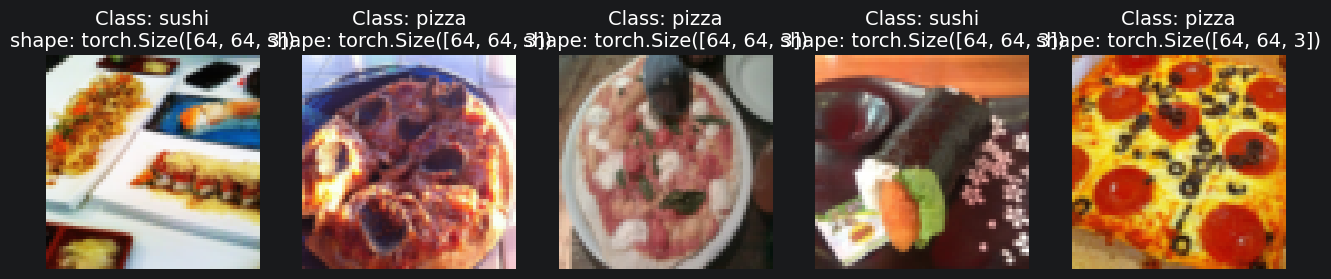

In [240]:
# Display random images
display_random_images(train_data, n=5, classes=class_names, seed=42)

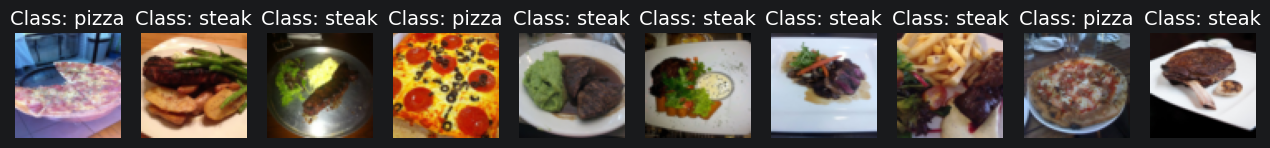

In [241]:
display_random_images(train_data_custom, n=20, classes=class_names, seed=42)

In [242]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset=train_data_custom, batch_size=BATCH_SIZE, num_workers=0, shuffle=True)
test_dataloader_custom = DataLoader(dataset=test_data_custom, batch_size=BATCH_SIZE, num_workers=0, shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x12a4ce350>,
 <torch.utils.data.dataloader.DataLoader at 0x12a569150>)

In [243]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

# 6.0 Other Forms of Transforms - Data Augmentation

Process of artificially adding diversity to training data

In the case of image data, this may mean applying various image transformations to the training images

* rotate, shift, zoom etc.



In [244]:
# TrivialAugment

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
])

In [245]:
# Get all image paths

image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3424937.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg')]

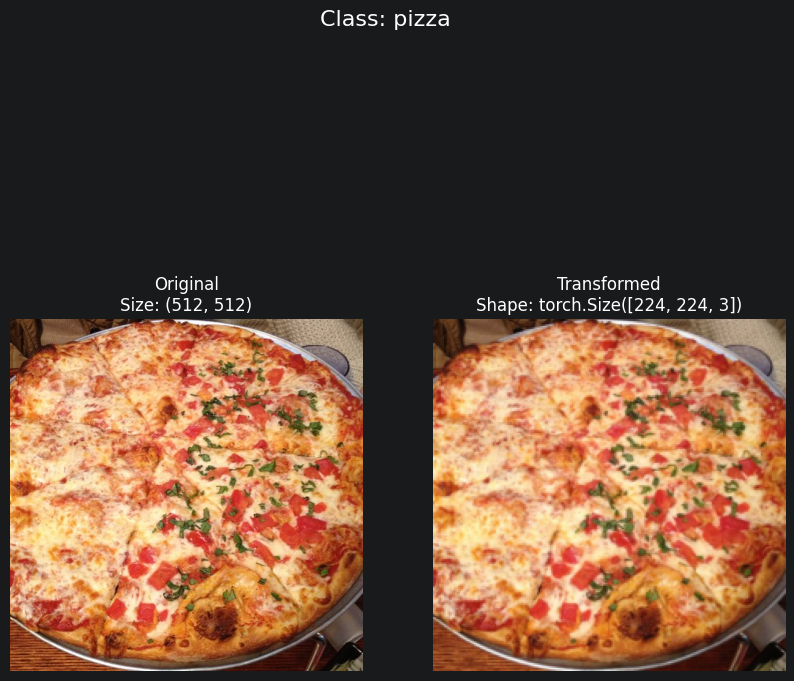

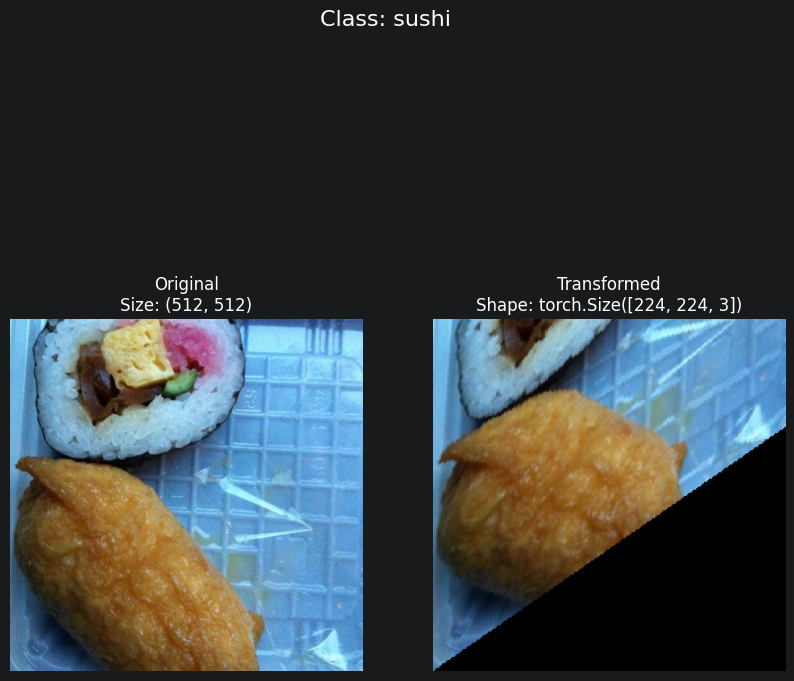

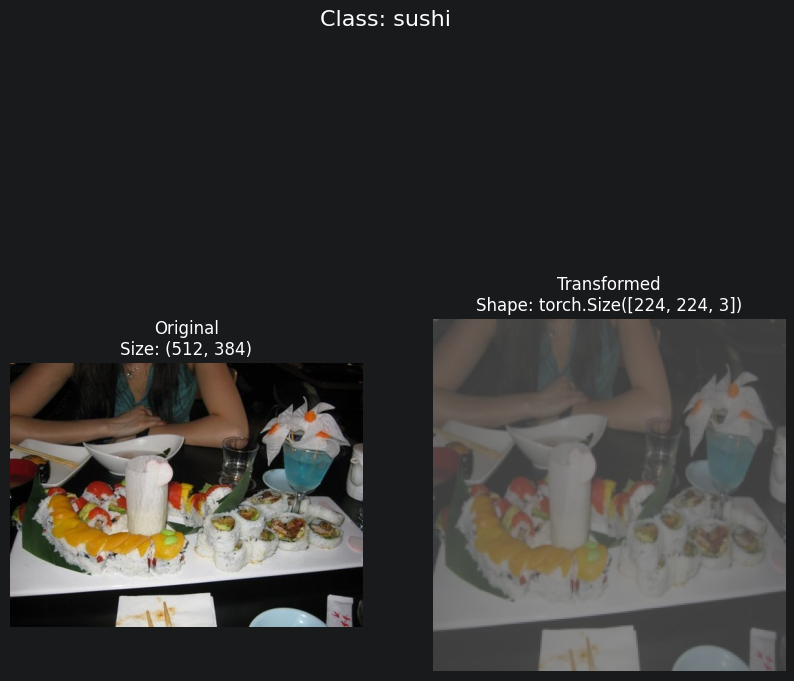

In [246]:
# Plot random images
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transform,
                        n=3,
                        seed=None)

# 7.0 Model 0: TinyVGG without data augmentation

replicating TinyVGG from CNN Explainer: https://poloclub.github.io/cnn-explainer/

# 7.1 Creating transforms and loading data for Model 0

In [247]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
])

In [248]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn datasets in DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0

train_data_loader_simple = DataLoader(dataset=train_data_simple, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
test_data_loader_simple = DataLoader(dataset=test_data_simple, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)



In [249]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 13 * 13, out_features=output_shape),
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x


In [250]:
torch.manual_seed(42)

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)
                 ).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

# 7.3 Try a forward pass on a single image

In [251]:
# get a single image batch
image_batch, label_batch = next(iter(train_data_loader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [252]:
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0047e-03],
        [ 2.0996e-02,  1.6416e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0238e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4989e-03],
        [ 2.2101e-02, -4.1470e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2131e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

# 7.4 Use torchinfo to get summary on Model

In [253]:
from torchinfo import summary

summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

# 7.5 Create train and test loop functions

* `train_step()` - takes in a model ad dataloader and trains the model on the dataloader
* `test_step()` - takes in a model and dataloader and evaluates the model on the dataloader
* `train()` - loops over epochs and calls train_step() and test_step()

In [254]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()

    # set up train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # loop through data loader
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [255]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        return test_loss, test_acc

# 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [256]:
from tqdm import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device: torch.device = device):

    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")


        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results


# 7.7 Train and Evaluate Model 0

In [277]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.mps.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_data_loader_simple,
                        test_dataloader=test_data_loader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

end_time = timer()
print(f"Total train time: {end_time - start_time: .3f}")


 20%|██        | 1/5 [00:00<00:02,  1.93it/s]

Epoch: 0 | Train loss: 1.1063 | Train acc: 0.3047 | Test loss: 1.0983 | Test acc: 0.3011


 40%|████      | 2/5 [00:01<00:01,  1.94it/s]

Epoch: 1 | Train loss: 1.0998 | Train acc: 0.3281 | Test loss: 1.0697 | Test acc: 0.5417


 60%|██████    | 3/5 [00:01<00:01,  1.96it/s]

Epoch: 2 | Train loss: 1.0869 | Train acc: 0.4883 | Test loss: 1.0808 | Test acc: 0.4924


 80%|████████  | 4/5 [00:02<00:00,  2.00it/s]

Epoch: 3 | Train loss: 1.0844 | Train acc: 0.4023 | Test loss: 1.0607 | Test acc: 0.5833


100%|██████████| 5/5 [00:02<00:00,  1.99it/s]

Epoch: 4 | Train loss: 1.0663 | Train acc: 0.4180 | Test loss: 1.0658 | Test acc: 0.5644
Total train time:  2.513


# 7.8 Plot the loss curves of Model 0

Way of tracking model's progress over time.

In [263]:
# Get model_0 results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [266]:
def plot_loss_curves(results: dict[str, list[float]]):
    """
    plots training curves of a results dictionary
    :param results:
    :type results:
    :return:
    :rtype:
    """
    # Get loss values of results dictionary
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Get accuracy
    acc = results["train_acc"]
    test_acc = results["test_acc"]

    # Figure out how many epochs there were
    epochs = range(len(results["train_loss"]))

    # Setup plot
    plt.figure(figsize=(15, 7))

    # Plot the loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, test_loss, label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot the accuracty
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, test_acc, label="Test Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()




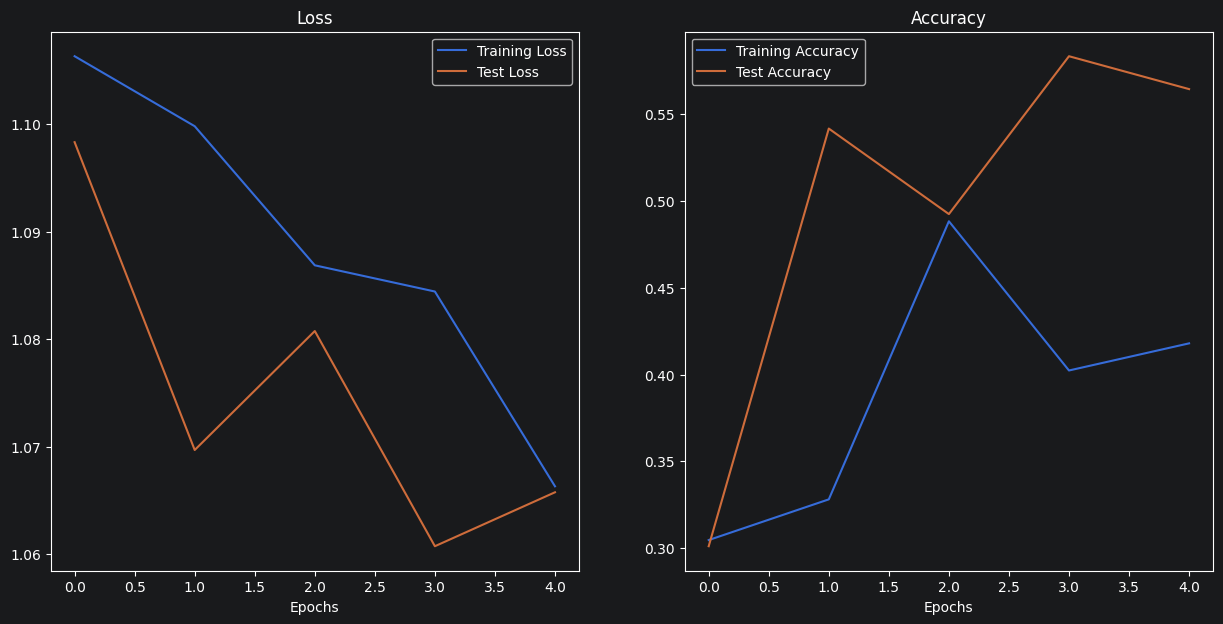

In [278]:
plot_loss_curves(model_0_results)

# 8.0 What should an ideal loss curve look like?

A loss curve is one of the most helpful ways to troubleshoot a model

# 9.0 Model 1: TinyVGG with Data Augmentation

Same model as before with some data augmentation

# 9.1 Create Transform wth data augmentation

In [268]:
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
])

test_transform_simple = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# 9.2 Create train and test Datasets and DataLoaders with data augmentation

In [273]:
# 1. Load and transform data
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir, transform=train_transform_trivial)
test_data_simple= datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn datasets in DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0

torch.manual_seed(42)

train_data_loader_augmented = DataLoader(dataset=train_data_augmented, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
test_data_loader_simple = DataLoader(dataset=test_data_simple, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# 9.3 Construct and train Model 1

In [280]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.mps.manual_seed(42)

NUM_EPOCHS = 5

model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_augmented.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_1_results = train(model=model_1,
                        train_dataloader=train_data_loader_augmented,
                        test_dataloader=test_data_loader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

end_time = timer()
print(f"Total train time: {end_time - start_time: .3f}")

 20%|██        | 1/5 [00:00<00:03,  1.22it/s]

Epoch: 0 | Train loss: 1.1069 | Train acc: 0.3086 | Test loss: 1.0993 | Test acc: 0.2708


 40%|████      | 2/5 [00:01<00:02,  1.37it/s]

Epoch: 1 | Train loss: 1.0872 | Train acc: 0.4102 | Test loss: 1.0615 | Test acc: 0.5417


 60%|██████    | 3/5 [00:02<00:01,  1.57it/s]

Epoch: 2 | Train loss: 1.1272 | Train acc: 0.2812 | Test loss: 1.0456 | Test acc: 0.5417


 80%|████████  | 4/5 [00:02<00:00,  1.69it/s]

Epoch: 3 | Train loss: 1.0991 | Train acc: 0.2891 | Test loss: 1.0925 | Test acc: 0.1979


100%|██████████| 5/5 [00:03<00:00,  1.64it/s]

Epoch: 4 | Train loss: 1.1118 | Train acc: 0.3477 | Test loss: 1.0774 | Test acc: 0.5729
Total train time:  3.058


# 9.4 Plot Loss Curves of Model 1

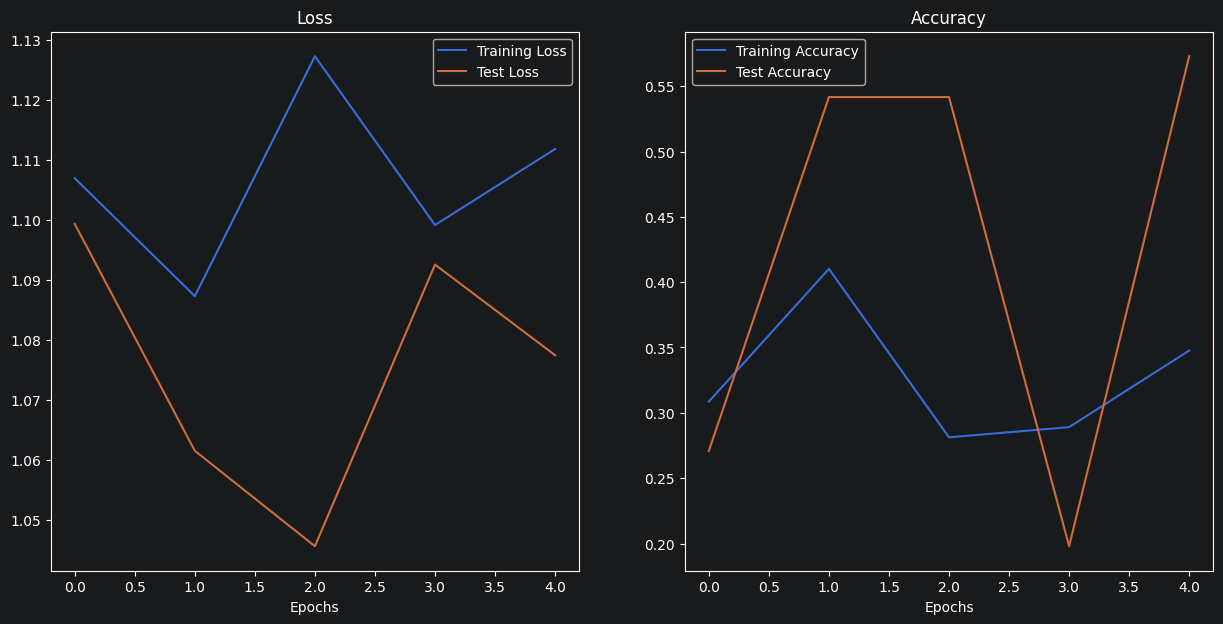

In [281]:
plot_loss_curves(model_1_results)

# 10 Compare Model Results

After evaluating modelling experiments it's important to compare them to each other.



In [283]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098322,0.301136
1,1.099807,0.328125,1.069683,0.541667
2,1.086866,0.488281,1.080751,0.492424
3,1.084428,0.402344,1.060732,0.583333
4,1.066306,0.417969,1.065750,0.564394


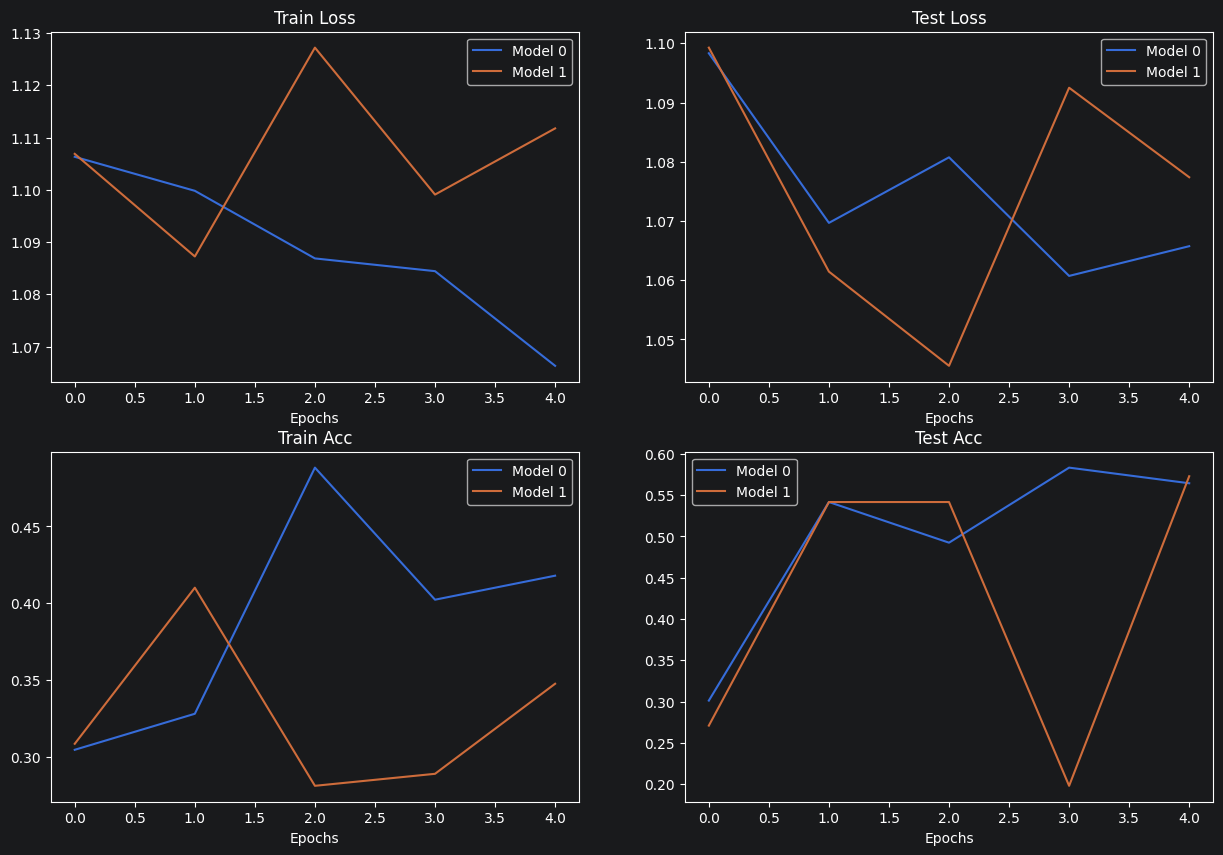

In [287]:
# Set up a plost

plt.figure(figsize=(15, 10))

epochs = range(len(model_0_df))

# plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# plot train acc
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Acc")
plt.xlabel("Epochs")
plt.legend()

# plot test acc
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Acc")
plt.xlabel("Epochs")
plt.legend()


# 11. Making a prediction on a custom image

In [288]:
import requests

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}")
        f.write(request.content)
else:
    print(f"Using custom image: {custom_image_path}")


# 11.1  Loading in a custom image with PyTorch

We have to make sure our custom image is in the same format as the data our model was trained on.

* Tensor (torch.float32)
* shape 64x64x3
* on the right device

In [289]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
custom_image_uint8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

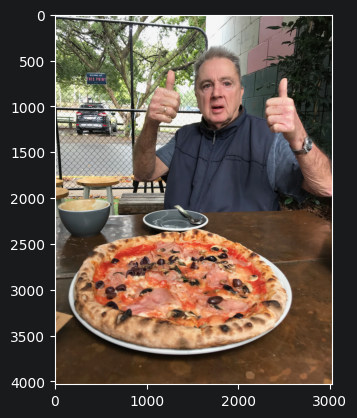

In [291]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))

In [293]:
custom_image_uint8.shape, custom_image_uint8.dtype

(torch.Size([3, 4032, 3024]), torch.uint8)

# 11.2 Making a prediction on a custom image with a trained PyTorch mode

In [309]:
# Create transform pipeline to resize image
from torchvision import transforms

custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.


custom_image_transformed = custom_image_transform(custom_image)
custom_image_transformed.shape

torch.Size([3, 64, 64])

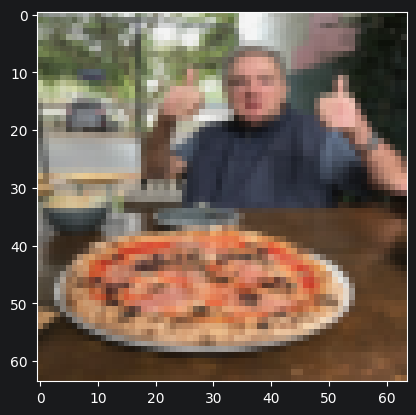

In [310]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [314]:
# Need to add batch size
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

custom_image_pred

tensor([[-0.0974, -0.0448,  0.0061]], device='mps:0')

In [315]:
class_names

['pizza', 'steak', 'sushi']

In [316]:
# Convert logits - > prediction probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

tensor([[0.3161, 0.3332, 0.3506]], device='mps:0')

In [318]:
# convert prediction probabilities to labels
custom_image_pred_labels = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_labels

tensor([2], device='mps:0')

In [319]:
class_names[custom_image_pred_labels]

'sushi'

# 11.3 Putting custom image prediction together: Building a function

A function where we pass an image path to and have our model predict on that image


In [325]:
def predict_image(image_path: Path, model: torch.nn.Module) -> str:
    image_tensor = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255.

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
    ])
    image = transform(image_tensor).unsqueeze(0).to(device)
    with torch.inference_mode():
        image_pred = model(image)
        image_pred_probs = torch.softmax(image_pred, dim=1)
        image_pred_labels = torch.argmax(image_pred_probs, dim=1)
        return class_names[image_pred_labels]



In [326]:
predict_image(custom_image_path, model_1)

'sushi'